In [ ]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 94% 154M/163M [00:00<00:00, 1.61GB/s]
100% 163M/163M [00:00<00:00, 1.58GB/s]


In [ ]:
from zipfile import ZipFile

with ZipFile('face-mask-dataset.zip', 'r') as zip:
    zip.extractall('face_mask_dataset')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
with_mask_path = '/content/face_mask_dataset/data/with_mask'
without_mask_path = '/content/face_mask_dataset/data/without_mask'

with_mask_files = os.listdir(with_mask_path)
without_mask_files = os.listdir(without_mask_path)

print("With Mask samples:", with_mask_files[:5])
print("Without Mask samples:", without_mask_files[:5])

print("Number of with mask images:", len(with_mask_files))
print("Number of without mask images:", len(without_mask_files))

With Mask samples: ['with_mask_2024.jpg', 'with_mask_1904.jpg', 'with_mask_1633.jpg', 'with_mask_3596.jpg', 'with_mask_446.jpg']
Without Mask samples: ['without_mask_808.jpg', 'without_mask_938.jpg', 'without_mask_2001.jpg', 'without_mask_2976.jpg', 'without_mask_3261.jpg']
Number of with mask images: 3725
Number of without mask images: 3828


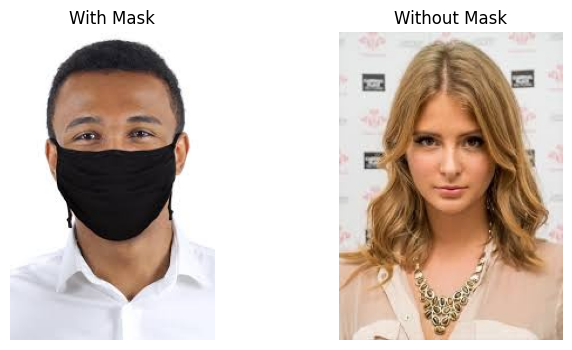

In [ ]:
img1 = Image.open(os.path.join(with_mask_path, with_mask_files[99]))
img2 = Image.open(os.path.join(without_mask_path, without_mask_files[34]))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("With Mask")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("Without Mask")
plt.axis('off')

plt.show()


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
dataset = datasets.ImageFolder(
    root='/content/face_mask_dataset/data',
    transform=transform
)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size]
)


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)#1000


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 5

for epoch in range(epochs):
    running_loss = 0
    correct = 0
    total = 0

    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss:.4f} Accuracy: {accuracy:.2f}%")


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/5] Loss: 42.9332 Accuracy: 92.24%
Epoch [2/5] Loss: 20.4926 Accuracy: 96.61%
Epoch [3/5] Loss: 15.5911 Accuracy: 97.32%
Epoch [4/5] Loss: 13.5136 Accuracy: 97.83%
Epoch [5/5] Loss: 12.6497 Accuracy: 97.96%


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 98.28%


In [ ]:
import numpy as np

def show_preds(model, dataloader, title):
    model.eval()

    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    preds  = preds.cpu().numpy()

    class_names = ['With Mask', 'Without Mask']

    idxs = np.random.choice(len(images), 6, replace=False)

    plt.figure(figsize=(12, 8))
    plt.suptitle(title, fontsize=16)

    for i, idx in enumerate(idxs):
        plt.subplot(2, 3, i + 1)

        img = images[idx].transpose((1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(f"Pred: {class_names[preds[idx]]}\nTrue: {class_names[labels[idx]]}")
        plt.axis('off')

    plt.show()


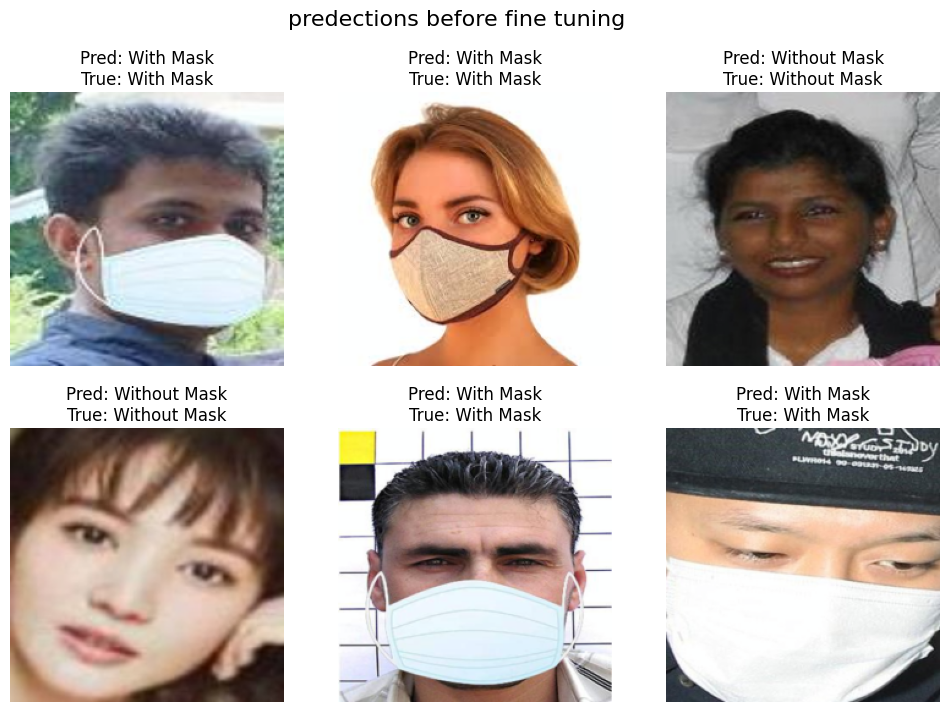

In [ ]:
show_preds(model , test_loader, 'predections before fine tuning ')